In [11]:
# Aadhaar Biometric Update Analysis
Objective: Identify update patterns and system inefficiencies


SyntaxError: invalid syntax (2013485833.py, line 2)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import glob

data_path = r"C:\Users\venka\Downloads\api_data_aadhar_biometric\api_data_aadhar_biometric\*.csv"

files = glob.glob(data_path)
files


['C:\\Users\\venka\\Downloads\\api_data_aadhar_biometric\\api_data_aadhar_biometric\\api_data_aadhar_biometric_0_500000.csv',
 'C:\\Users\\venka\\Downloads\\api_data_aadhar_biometric\\api_data_aadhar_biometric\\api_data_aadhar_biometric_1000000_1500000.csv',
 'C:\\Users\\venka\\Downloads\\api_data_aadhar_biometric\\api_data_aadhar_biometric\\api_data_aadhar_biometric_1500000_1861108.csv',
 'C:\\Users\\venka\\Downloads\\api_data_aadhar_biometric\\api_data_aadhar_biometric\\api_data_aadhar_biometric_500000_1000000.csv']

In [15]:
df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True)

df.shape


(1861108, 6)

In [16]:
df.columns


Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')

In [17]:
list(df.columns)


['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']

In [18]:
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)


In [19]:
age_columns = [col for col in df.columns if col.startswith("bio_age")]
age_totals = df[age_columns].sum()


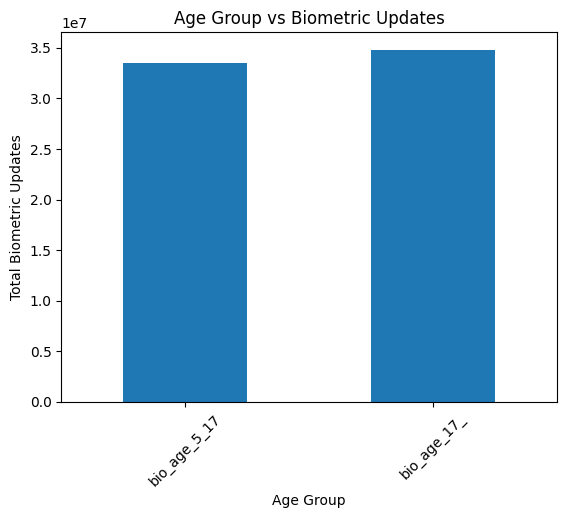

In [20]:
plt.figure()
age_totals.plot(kind="bar")
plt.xlabel("Age Group")
plt.ylabel("Total Biometric Updates")
plt.title("Age Group vs Biometric Updates")
plt.xticks(rotation=45)
plt.show()


In [21]:
df["total_updates"] = df[age_columns].sum(axis=1)


In [22]:
state_updates = (
    df.groupby("state")["total_updates"]
    .sum()
    .sort_values(ascending=False)
)


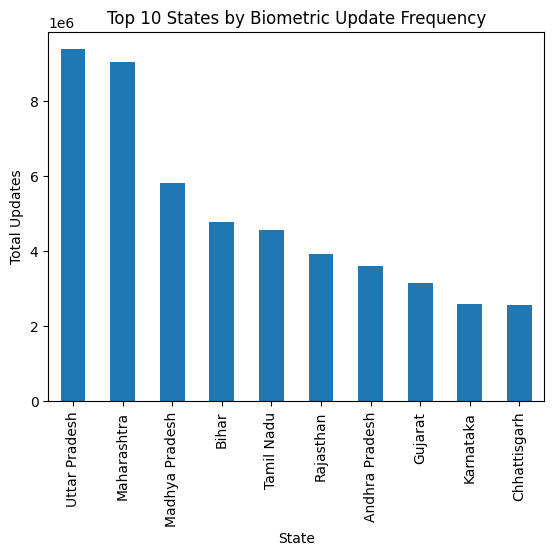

In [23]:
plt.figure()
state_updates.head(10).plot(kind="bar")
plt.xlabel("State")
plt.ylabel("Total Updates")
plt.title("Top 10 States by Biometric Update Frequency")
plt.show()


In [24]:
mean = df["total_updates"].mean()
std = df["total_updates"].std()


In [25]:
anomalies = df[df["total_updates"] > mean + 3*std]
anomalies.head()


,date,state,district,pincode,bio_age_5_17,bio_age_17_,total_updates
0,01-03-2025,Haryana,Mahendragarh,123029,280,577,857
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091,1734
3,01-03-2025,Bihar,Bhojpur,802158,256,980,1236
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815,1086
5,01-03-2025,Maharashtra,Ratnagiri,416702,155,529,684


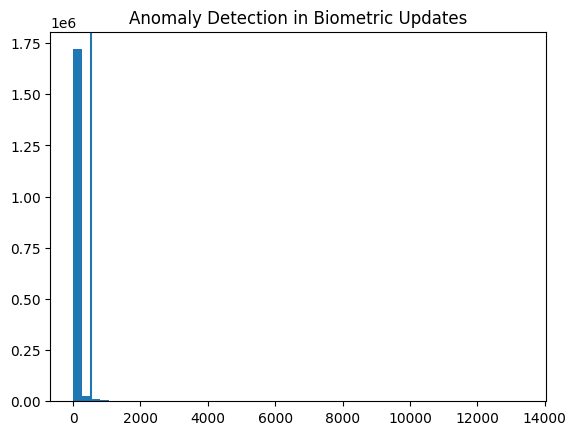

In [26]:
plt.figure()
plt.hist(df["total_updates"], bins=50)
plt.axvline(mean + 3*std)
plt.title("Anomaly Detection in Biometric Updates")
plt.show()


In [27]:
df.to_csv("clean_aadhaar_biometric.csv", index=False)


PermissionError: [Errno 13] Permission denied: 'clean_aadhaar_biometric.csv'

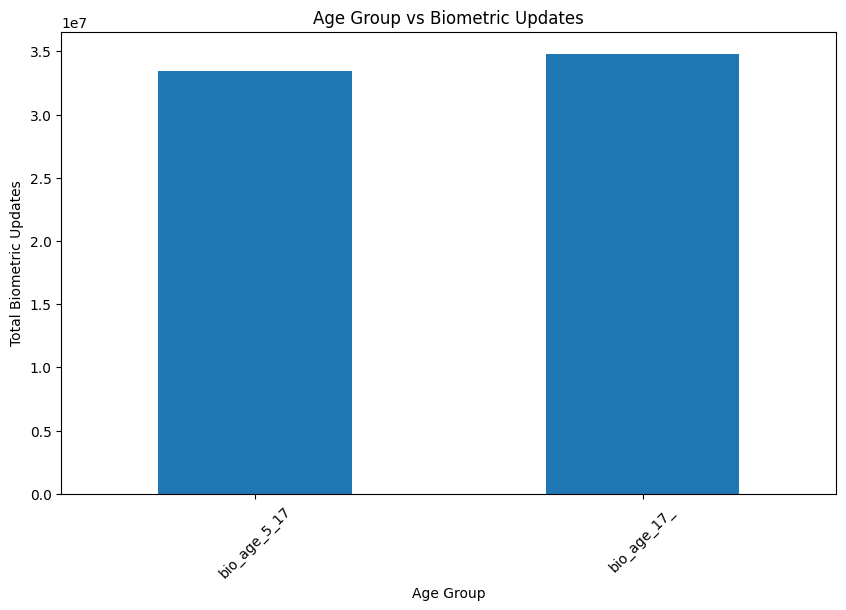

In [28]:
plt.figure(figsize=(10,6))
age_totals.plot(kind="bar")
plt.xlabel("Age Group")
plt.ylabel("Total Biometric Updates")
plt.title("Age Group vs Biometric Updates")
plt.xticks(rotation=45)

plt.savefig("age_vs_biometric_updates.png", bbox_inches="tight")
plt.show()


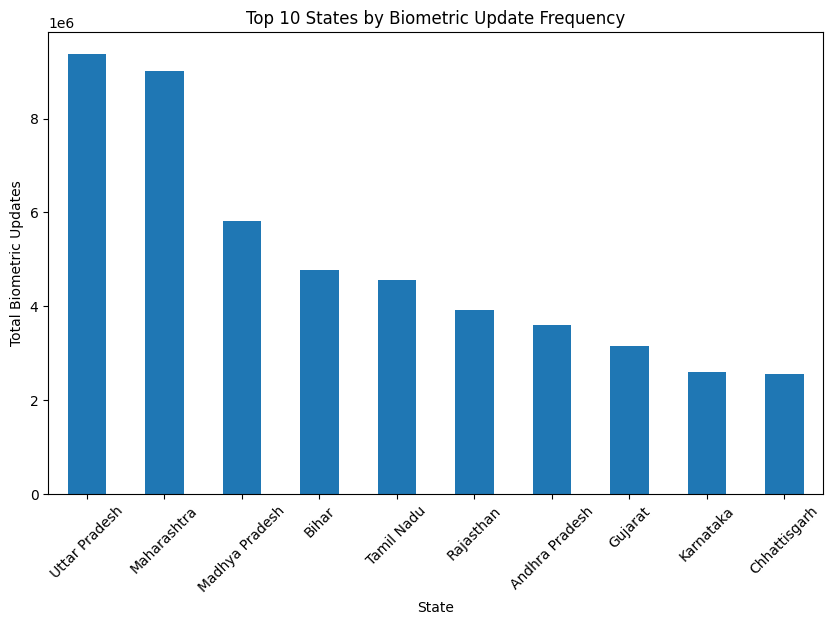

In [29]:
plt.figure(figsize=(10,6))
state_updates.head(10).plot(kind="bar")
plt.xlabel("State")
plt.ylabel("Total Biometric Updates")
plt.title("Top 10 States by Biometric Update Frequency")
plt.xticks(rotation=45)

plt.savefig("state_wise_biometric_updates.png", bbox_inches="tight")
plt.show()


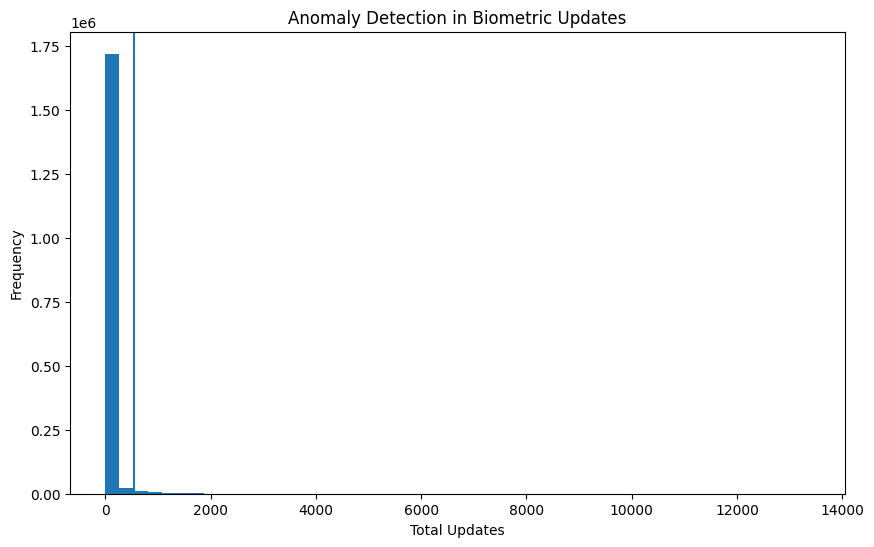

In [30]:
plt.figure(figsize=(10,6))
plt.hist(df["total_updates"], bins=50)
plt.axvline(mean + 3*std)
plt.xlabel("Total Updates")
plt.ylabel("Frequency")
plt.title("Anomaly Detection in Biometric Updates")

plt.savefig("biometric_update_anomalies.png", bbox_inches="tight")

plt.show()


In [ ]:
### Insight 1: Age vs Biometric Updates
Higher biometric update frequency is observed in children and elderly age groups. This is likely due to biometric instability caused by growth in children and degradation of fingerprints and facial features in older individuals.

### Insight 2: State-wise Update Frequency
Certain states show disproportionately high biometric update counts. While population contributes to this, repeated updates may also indicate infrastructure stress or biometric enrollment quality issues.

### Insight 3: Unusual Spikes and Anomalies
The anomaly detection highlights extreme spikes in biometric updates that exceed normal statistical thresholds. These spikes suggest enrollment drives, system overload, or unreliable biometric capture devices rather than normal user behavior.

### System Inefficiency Summary
Repeated biometric updates across specific age groups and regions indicate inefficiencies in biometric reliability and enrollment infrastructure. Improving sensor quality and standardizing enrollment procedures can significantly reduce unnecessary updates.


In [ ]:
### Key Anomalies and Inefficiencies

- Higher biometric updates observed in child and elderly age groups due to biometric instability.
- Certain states exhibit disproportionately high update frequencies.
- Extreme spikes suggest enrollment drives, biometric mismatches, or infrastructure overload.
- These patterns indicate system-level inefficiencies rather than individual behavior.


In [ ]:
### Conclusion

The analysis of Aadhaar biometric updates highlights age-dependent biometric reliability issues and regional disparities in update frequency. Anomaly detection reveals operational inefficiencies in biometric enrollment systems. Improving biometric capture quality and regional infrastructure can significantly reduce repeated updates.
